In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
import os
import cv2
from tensorflow import keras
from tensorflow.keras.layers import Bidirectional, Dropout, Activation, Dense, LSTM
from tensorflow.keras.models import Sequential
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

In [105]:
images = []
for image in os.listdir('./'):
    if image.lower().endswith('jpg'):
        i = cv2.imread(image)
        i = cv2.cvtColor(i, cv2.COLOR_BGR2RGB) 
        i = i / 256
        i = cv2.resize(i, (1024, 1024))
        i = i.reshape(1024 * 1024 * 3, )
        images.append(i)

In [106]:
images = np.array(images)

In [2]:
data = pd.read_csv("HungaryChickenpox.csv")

In [3]:
data.head()

,Date,BUDAPEST,BARANYA,BACS,BEKES,BORSOD,CSONGRAD,FEJER,GYOR,HAJDU,...,JASZ,KOMAROM,NOGRAD,PEST,SOMOGY,SZABOLCS,TOLNA,VAS,VESZPREM,ZALA
0,03/01/2005,168,79,30,173,169,42,136,120,162,...,130,57,2,178,66,64,11,29,87,68
1,10/01/2005,157,60,30,92,200,53,51,70,84,...,80,50,29,141,48,29,58,53,68,26
2,17/01/2005,96,44,31,86,93,30,93,84,191,...,64,46,4,157,33,33,24,18,62,44
3,24/01/2005,163,49,43,126,46,39,52,114,107,...,63,54,14,107,66,50,25,21,43,31
4,31/01/2005,122,78,53,87,103,34,95,131,172,...,61,49,11,124,63,56,7,47,85,60


In [4]:
X = data#.drop(columns = ["BARANYA", "BACS", "BEKES", "BORSOD", "CSONGRAD", "FEJER", "GYOR", "HAJDU", "HEVES", "JASZ", "KOMAROM", "NOGRAD", "PEST", "SOMOGY", "SZABOLCS", "TOLNA", "VAS", "VESZPREM", "ZALA"])

In [5]:
X.head()

,Date,BUDAPEST,BARANYA,BACS,BEKES,BORSOD,CSONGRAD,FEJER,GYOR,HAJDU,...,JASZ,KOMAROM,NOGRAD,PEST,SOMOGY,SZABOLCS,TOLNA,VAS,VESZPREM,ZALA
0,03/01/2005,168,79,30,173,169,42,136,120,162,...,130,57,2,178,66,64,11,29,87,68
1,10/01/2005,157,60,30,92,200,53,51,70,84,...,80,50,29,141,48,29,58,53,68,26
2,17/01/2005,96,44,31,86,93,30,93,84,191,...,64,46,4,157,33,33,24,18,62,44
3,24/01/2005,163,49,43,126,46,39,52,114,107,...,63,54,14,107,66,50,25,21,43,31
4,31/01/2005,122,78,53,87,103,34,95,131,172,...,61,49,11,124,63,56,7,47,85,60


Text(0.5, 1.0, 'ChickenPoxTimeSeries')

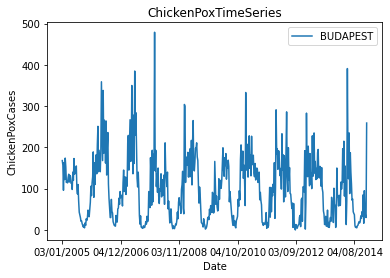

In [6]:
ax = X.plot(x = 'Date', y = 'BUDAPEST');
ax.set_xlabel('Date')
ax.set_ylabel('ChickenPoxCases')
ax.set_title('ChickenPoxTimeSeries')

In [7]:
scaler = MinMaxScaler()
CPox = X.BUDAPEST.values.reshape(-1, 1)
scaled_CPox = scaler.fit_transform(CPox)
CPOX = np.zeros((20, 522, 1))
CPOX[0] = scaled_CPox
j = 1
for i in ["BARANYA", "BACS", "BEKES", "BORSOD", "CSONGRAD", "FEJER", "GYOR", "HAJDU", "HEVES", "JASZ", "KOMAROM", "NOGRAD", "PEST", "SOMOGY", "SZABOLCS", "TOLNA", "VAS", "VESZPREM", "ZALA"]:
    CPox = X[i].values.reshape(-1, 1)
    scaled_CPox = scaler.fit_transform(CPox)
    CPOX[j] = scaled_CPox
    j += 1

In [8]:
CPOX = CPOX.reshape((522, 20))
print(CPOX[0])

[0.35073069 0.32776618 0.20041754 0.34029228 0.25469729 0.36325678
 0.31941545 0.24008351 0.24843424 0.23799582 0.2651357  0.28183716
 0.24217119 0.27557411 0.26931106 0.23590814 0.23799582 0.2045929
 0.29227557 0.25052192]


In [12]:
seq_len = 60

def split_into_sequences(data, seq_len):
    n_seq = len(data) - seq_len + 1
    return np.array([data[i:(i + seq_len)] for i in range(n_seq)])

def get_train_test_sets(data, seq_len, train_frac):
    sequences = split_into_sequences(data, seq_len)
    n_train = int(sequences.shape[0] * train_frac)
    x_train = sequences[:n_train, :-1, :]
    y_train = sequences[:n_train, -1, :]
    x_test = sequences[n_train:, :-1, :]
    y_test = sequences[n_train:, -1, :]
    return x_train, y_train, x_test, y_test

X_Train, Y_Train, X_Test, Y_Test = get_train_test_sets(CPOX, seq_len, train_frac = 0.9)

In [140]:
X_Train, Y_Train, X_Test, Y_Test = get_train_test_sets(images, seq_len, train_frac = 0.9)

In [13]:
print(X_Train.shape, Y_Train.shape, X_Test.shape, Y_Test.shape)

(416, 59, 20) (416, 20) (47, 59, 20) (47, 20)


In [53]:
# X_Train = X_Train.reshape((X_Train.shape[0], X_Train.shape[1], X_Train.shape[3]))
# Y_Train = Y_Train.reshape((Y_Train.shape[0], Y_Train.shape[2]))
# X_Test = X_Test.reshape((X_Test.shape[0], X_Test.shape[1], X_Test.shape[3]))
# Y_Test = Y_Test.reshape((Y_Test.shape[0], Y_Test.shape[2]))

In [14]:
print(X_Train.shape, Y_Train.shape)

(416, 59, 20) (416, 20)


In [15]:
print(X_Train[0], Y_Train[0])

[[0.35073069 0.32776618 0.20041754 ... 0.2045929  0.29227557 0.25052192]
 [0.3611691  0.28183716 0.29853862 ... 0.02505219 0.01043841 0.03549061]
 [0.02296451 0.05636743 0.0480167  ... 0.32985386 0.37995825 0.28392484]
 ...
 [0.23722628 0.20437956 0.09124088 ... 0.03284672 0.03649635 0.06569343]
 [0.06934307 0.14233577 0.05109489 ... 0.2810219  0.08029197 0.32481752]
 [0.22262774 0.25182482 0.21532847 ... 0.06934307 0.02189781 0.01824818]] [0.02189781 0.00364964 0.00729927 0.01459854 0.00729927 0.00729927
 0.01459854 0.02189781 0.04379562 0.0729927  0.12408759 0.03284672
 0.17518248 0.12408759 0.10583942 0.1459854  0.13138686 0.18978102
 0.13868613 0.11313869]


In [16]:
dropout = 0.2
window_size = seq_len - 1
model = keras.Sequential()

model.add(
    LSTM(window_size, return_sequences = True, 
         input_shape = (window_size, X_Train.shape[-1]))
)

model.add(Dropout(rate = dropout))
model.add(
    Bidirectional(LSTM((window_size * 2), return_sequences = True)
))

model.add(Dropout(rate = dropout))
model.add(
    Bidirectional(LSTM((window_size * 2), return_sequences = True)
))

model.add(Dropout(rate = dropout))
model.add(
    Bidirectional(LSTM(window_size, return_sequences = False))
) 

model.add(Dense(units = 20))
model.add(Activation('linear'))

In [17]:
model.compile(loss = "mean_squared_error", optimizer = "adam")

In [19]:
model.fit(X_Train, Y_Train, epochs = 500, shuffle = False)

Epoch 1/500
13/13 [==============================] - 1s 51ms/step - loss: 0.0296
Epoch 2/500
13/13 [==============================] - 1s 47ms/step - loss: 0.0299
Epoch 3/500
13/13 [==============================] - 1s 45ms/step - loss: 0.0298
Epoch 4/500
13/13 [==============================] - 1s 47ms/step - loss: 0.0297
Epoch 5/500
13/13 [==============================] - 1s 46ms/step - loss: 0.0295
Epoch 6/500
13/13 [==============================] - 1s 47ms/step - loss: 0.0294
Epoch 7/500
13/13 [==============================] - 1s 48ms/step - loss: 0.0292
Epoch 8/500
13/13 [==============================] - 1s 48ms/step - loss: 0.0289
Epoch 9/500
13/13 [==============================] - 1s 39ms/step - loss: 0.0287
Epoch 10/500
13/13 [==============================] - 1s 39ms/step - loss: 0.0285
Epoch 11/500
13/13 [==============================] - 1s 39ms/step - loss: 0.0282
Epoch 12/500
13/13 [==============================] - 1s 39ms/step - loss: 0.0282
Epoch 13/500
13/13 [=====

13/13 [==============================] - 1s 40ms/step - loss: 0.0104
Epoch 102/500
13/13 [==============================] - 1s 41ms/step - loss: 0.0098
Epoch 103/500
13/13 [==============================] - 1s 41ms/step - loss: 0.0099
Epoch 104/500
13/13 [==============================] - 1s 41ms/step - loss: 0.0097
Epoch 105/500
13/13 [==============================] - 1s 40ms/step - loss: 0.0101
Epoch 106/500
13/13 [==============================] - 1s 40ms/step - loss: 0.0100
Epoch 107/500
13/13 [==============================] - 1s 40ms/step - loss: 0.0097
Epoch 108/500
13/13 [==============================] - 1s 41ms/step - loss: 0.0098
Epoch 109/500
13/13 [==============================] - 1s 41ms/step - loss: 0.0100
Epoch 110/500
13/13 [==============================] - 1s 40ms/step - loss: 0.0105
Epoch 111/500
13/13 [==============================] - 1s 42ms/step - loss: 0.0107
Epoch 112/500
13/13 [==============================] - 1s 48ms/step - loss: 0.0100
Epoch 113/500
13/1

13/13 [==============================] - 1s 41ms/step - loss: 0.0016
Epoch 298/500
13/13 [==============================] - 1s 41ms/step - loss: 0.0016
Epoch 299/500
13/13 [==============================] - 1s 41ms/step - loss: 0.0016
Epoch 300/500
13/13 [==============================] - 1s 41ms/step - loss: 0.0016
Epoch 301/500
13/13 [==============================] - 1s 40ms/step - loss: 0.0015
Epoch 302/500
13/13 [==============================] - 1s 40ms/step - loss: 0.0014
Epoch 303/500
13/13 [==============================] - 1s 39ms/step - loss: 0.0014
Epoch 304/500
13/13 [==============================] - 1s 43ms/step - loss: 0.0014
Epoch 305/500
13/13 [==============================] - 1s 40ms/step - loss: 0.0014
Epoch 306/500
13/13 [==============================] - 1s 42ms/step - loss: 0.0014
Epoch 307/500
13/13 [==============================] - 1s 41ms/step - loss: 0.0014
Epoch 308/500
13/13 [==============================] - 1s 40ms/step - loss: 0.0014
Epoch 309/500
13/1

13/13 [==============================] - 1s 44ms/step - loss: 7.9080e-04
Epoch 491/500
13/13 [==============================] - 1s 43ms/step - loss: 8.8754e-04
Epoch 492/500
13/13 [==============================] - 1s 44ms/step - loss: 8.2516e-04
Epoch 493/500
13/13 [==============================] - 1s 42ms/step - loss: 8.2329e-04
Epoch 494/500
13/13 [==============================] - 1s 41ms/step - loss: 7.9717e-04
Epoch 495/500
13/13 [==============================] - 1s 42ms/step - loss: 8.2562e-04
Epoch 496/500
13/13 [==============================] - 1s 42ms/step - loss: 7.8362e-04
Epoch 497/500
13/13 [==============================] - 1s 44ms/step - loss: 7.6042e-04
Epoch 498/500
13/13 [==============================] - 1s 43ms/step - loss: 7.7542e-04
Epoch 499/500
13/13 [==============================] - 1s 42ms/step - loss: 7.4697e-04
Epoch 500/500
13/13 [==============================] - 1s 42ms/step - loss: 7.1566e-04


In [14]:
batch_size = 16
history = model.fit(X_Train, Y_Train, epochs = 500, batch_size = batch_size, shuffle = False, validation_split = 0.2)

Epoch 1/500
21/21 [==============================] - 22s 234ms/step - loss: 0.0314 - val_loss: 0.0341
Epoch 2/500
21/21 [==============================] - 1s 56ms/step - loss: 0.0323 - val_loss: 0.0333
Epoch 3/500
21/21 [==============================] - 1s 53ms/step - loss: 0.0301 - val_loss: 0.0327
Epoch 4/500
21/21 [==============================] - 1s 55ms/step - loss: 0.0293 - val_loss: 0.0326
Epoch 5/500
21/21 [==============================] - 1s 54ms/step - loss: 0.0291 - val_loss: 0.0327
Epoch 6/500
21/21 [==============================] - 1s 53ms/step - loss: 0.0289 - val_loss: 0.0332
Epoch 7/500
21/21 [==============================] - 1s 52ms/step - loss: 0.0291 - val_loss: 0.0322
Epoch 8/500
21/21 [==============================] - 1s 53ms/step - loss: 0.0278 - val_loss: 0.0318
Epoch 9/500
21/21 [==============================] - 1s 58ms/step - loss: 0.0277 - val_loss: 0.0317
Epoch 10/500
21/21 [==============================] - 1s 52ms/step - loss: 0.0278 - val_loss: 0.03

21/21 [==============================] - 1s 52ms/step - loss: 0.0030 - val_loss: 0.0367
Epoch 163/500
21/21 [==============================] - 1s 54ms/step - loss: 0.0029 - val_loss: 0.0348
Epoch 164/500
21/21 [==============================] - 1s 52ms/step - loss: 0.0030 - val_loss: 0.0364
Epoch 165/500
21/21 [==============================] - 1s 52ms/step - loss: 0.0030 - val_loss: 0.0365
Epoch 166/500
21/21 [==============================] - 1s 53ms/step - loss: 0.0028 - val_loss: 0.0367
Epoch 167/500
21/21 [==============================] - 1s 54ms/step - loss: 0.0027 - val_loss: 0.0364
Epoch 168/500
21/21 [==============================] - 1s 53ms/step - loss: 0.0030 - val_loss: 0.0327
Epoch 169/500
21/21 [==============================] - 1s 54ms/step - loss: 0.0029 - val_loss: 0.0330
Epoch 170/500
21/21 [==============================] - 1s 53ms/step - loss: 0.0025 - val_loss: 0.0372
Epoch 171/500
21/21 [==============================] - 1s 53ms/step - loss: 0.0025 - val_loss: 0

21/21 [==============================] - 1s 54ms/step - loss: 0.0016 - val_loss: 0.0304
Epoch 323/500
21/21 [==============================] - 1s 55ms/step - loss: 0.0014 - val_loss: 0.0300
Epoch 324/500
21/21 [==============================] - 1s 53ms/step - loss: 0.0016 - val_loss: 0.0295
Epoch 325/500
21/21 [==============================] - 1s 54ms/step - loss: 0.0014 - val_loss: 0.0307
Epoch 326/500
21/21 [==============================] - 1s 54ms/step - loss: 0.0014 - val_loss: 0.0329
Epoch 327/500
21/21 [==============================] - 1s 53ms/step - loss: 0.0013 - val_loss: 0.0294
Epoch 328/500
21/21 [==============================] - 1s 53ms/step - loss: 0.0012 - val_loss: 0.0296
Epoch 329/500
21/21 [==============================] - 1s 53ms/step - loss: 0.0012 - val_loss: 0.0312
Epoch 330/500
21/21 [==============================] - 1s 54ms/step - loss: 0.0011 - val_loss: 0.0302
Epoch 331/500
21/21 [==============================] - 1s 54ms/step - loss: 9.7705e-04 - val_los

21/21 [==============================] - 1s 53ms/step - loss: 5.6497e-04 - val_loss: 0.0284
Epoch 478/500
21/21 [==============================] - 1s 58ms/step - loss: 5.2399e-04 - val_loss: 0.0283
Epoch 479/500
21/21 [==============================] - 1s 58ms/step - loss: 5.2535e-04 - val_loss: 0.0294
Epoch 480/500
21/21 [==============================] - 1s 57ms/step - loss: 5.7766e-04 - val_loss: 0.0289
Epoch 481/500
21/21 [==============================] - 1s 56ms/step - loss: 5.2785e-04 - val_loss: 0.0283
Epoch 482/500
21/21 [==============================] - 1s 56ms/step - loss: 5.2971e-04 - val_loss: 0.0293
Epoch 483/500
21/21 [==============================] - 1s 54ms/step - loss: 5.6305e-04 - val_loss: 0.0289
Epoch 484/500
21/21 [==============================] - 1s 53ms/step - loss: 5.4475e-04 - val_loss: 0.0282
Epoch 485/500
21/21 [==============================] - 1s 53ms/step - loss: 5.4928e-04 - val_loss: 0.0294
Epoch 486/500
21/21 [==============================] - 1s 52

In [20]:
Y_Pred = model.predict(X_Test)

2/2 [==============================] - 3s 44ms/step


In [21]:
print(Y_Pred.shape, Y_Test.shape)

(47, 20) (47, 20)


In [142]:
Y_Pred = Y_Pred.reshape(1024, 1024, 3)
Y_Test = Y_Test.reshape(1024, 1024, 3)

In [143]:
output_p = Y_Pred * 256
output_r = Y_Test * 256

In [138]:
output_p = cv2.resize(output_p, (1024, 1024))
output_r = cv2.resize(output_r, (1024, 1024))

In [145]:
cv2.imshow('Output_p', output_p.astype(np.uint8))
cv2.imshow('Output_r', output_r.astype(np.uint8))
cv2.waitKey(0)
cv2.destroyAllWindows()

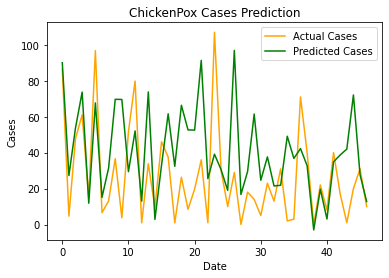

In [24]:
Y_Test_Orig = scaler.inverse_transform(Y_Test)
Y_Pred_Orig = scaler.inverse_transform(Y_Pred)

plt.plot(Y_Test_Orig[:,10:11], label = 'Actual Cases', color = 'orange')
plt.plot(Y_Pred_Orig[:,10:11], label = 'Predicted Cases', color = 'green')
 
plt.title('ChickenPox Cases Prediction')
plt.xlabel('Date')
plt.ylabel('Cases')
plt.legend(loc = 'best')

plt.show();